# Exploratory Data Analysis - *PositionReport* data

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re

What can be seen in the data is the fact that the header starts at row 9. Therefore, first 8 rows should be skipped.  

In [ ]:
df_position = pd.read_excel('/content/PositionReport.xlsx', sheet_name='SC CONNECTOR', skiprows=8)

In [ ]:
print("Data shape:", df_position.shape)
display(df_position.head(10))

Data shape: (156943, 8)


,Time,Lat,Lon,Speed\n[kn],Calculated\nSpeed\n[kn],Course\n[°],Distance since\nlast point\n[nm],Total distance\nrun\n[nm]
0,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-02-02 00:06:00,56° 49.6000' N,000° 07.7000' W,15.0,NaN,357.0,0.000000,0.000000
2,2023-02-02 00:21:00,56° 53.2000' N,000° 07.5000' W,15.0,14.4,47.0,3.608126,3.608126
3,2023-02-02 00:33:00,56° 55.4000' N,000° 03.5000' W,16.0,15.5,46.0,3.105603,6.713728
4,2023-02-02 00:54:00,56° 59.2000' N,000° 03.3000' E,15.0,15.2,44.0,5.318924,12.032653
5,2023-02-02 01:15:00,57° 03.0000' N,000° 10.5000' E,16.0,15.6,46.0,5.468927,17.501580
6,2023-02-02 01:33:00,57° 06.3000' N,000° 16.8000' E,16.0,15.9,48.0,4.763985,22.265565
7,2023-02-02 01:45:50,57° 08.4690' N,000° 21.3304' E,16.0,15.4,48.0,3.285002,25.550568
8,2023-02-02 01:58:32,57° 10.7088' N,000° 25.9707' E,16.2,15.9,47.0,3.374881,28.925449
9,2023-02-02 02:10:15,57° 12.6930' N,000° 30.4486' E,15.9,16.1,50.0,3.139759,32.065207


In [ ]:
print("Data shape before cleaning:", df_position.shape)

df_position = df_position.dropna(subset=['Time']).reset_index(drop=True)

df_position.columns = df_position.columns.str.replace('\n', ' ')

# column names standarization
rename_dict = {'Speed [kn]': 'Speed_kn', 'Calculated Speed [kn]': 'Calc_Speed_kn', 'Course [°]': 'Course_deg', 'Distance since last point [nm]': 'Dist_since_last_nm', 'Total distance run [nm]': 'Total_dist_nm'}

df_position = df_position.rename(columns=rename_dict)

print("Data shape after cleaning", df_position.shape)
display(df_position.head())

Data shape before cleaning: (156943, 8)
Data shape after cleaning (156942, 8)


,Time,Lat,Lon,Speed_kn,Calc_Speed_kn,Course_deg,Dist_since_last_nm,Total_dist_nm
0,2023-02-02 00:06:00,56° 49.6000' N,000° 07.7000' W,15.0,NaN,357.0,0.000000,0.000000
1,2023-02-02 00:21:00,56° 53.2000' N,000° 07.5000' W,15.0,14.4,47.0,3.608126,3.608126
2,2023-02-02 00:33:00,56° 55.4000' N,000° 03.5000' W,16.0,15.5,46.0,3.105603,6.713728
3,2023-02-02 00:54:00,56° 59.2000' N,000° 03.3000' E,15.0,15.2,44.0,5.318924,12.032653
4,2023-02-02 01:15:00,57° 03.0000' N,000° 10.5000' E,16.0,15.6,46.0,5.468927,17.501580


Apart from the 'nice formatting' of the Excel file, there is another aspect to consider. From human perspective, the `56° 49.6000' N` notation is highly readable. Howeber, for a computer this notation is treated as a string not a particular number. Therefore, we need to tranform it into a floating-point number, 56.8266.

In [ ]:
def parse_coordinates(coord_str):
    """
    Changing "56° 49.6000' N" string format for a decimal (float) format.
    """

    if pd.isna(coord_str):
        return np.nan

    match = re.search(r"(\d+)\s*°\s*([\d\.]+)\s*'\s*([NSEW])", str(coord_str))

    if match:
        degrees = float(match.group(1))
        minutes = float(match.group(2))
        direction = match.group(3)

        decimal = degrees + (minutes / 60.0)

        if direction in ['S', 'W']:
            decimal = -decimal

        return decimal
    return np.nan


df_position['Lat_dec'] = df_position['Lat'].apply(parse_coordinates)
df_position['Lon_dec'] = df_position['Lon'].apply(parse_coordinates)

display(df_position[['Lat', 'Lat_dec', 'Lon', 'Lon_dec']].head()) # comparing all columns - old ones - with the old notation and new ones - with the new notation

df_position.to_csv('/content/PositionReport_updated.csv', index=False)

,Lat,Lat_dec,Lon,Lon_dec
0,56° 49.6000' N,56.826667,000° 07.7000' W,-0.128333
1,56° 53.2000' N,56.886667,000° 07.5000' W,-0.125000
2,56° 55.4000' N,56.923333,000° 03.5000' W,-0.058333
3,56° 59.2000' N,56.986667,000° 03.3000' E,0.055000
4,57° 03.0000' N,57.050000,000° 10.5000' E,0.175000


## 1. Temporal analysis

As we saw in the data, the dataset comprises the continuous time period of 3 years (2023-2026). However, in real-life scenario, the ship does not move constantly. Apart from travelling, it visits the ports to unload the cargo or stays still at anchor. In the worst case scenario, there is also a possiblity that its Automatic Identification System (AIS) may lose coverage on the high seas.

Therefore, we would like to understand the actual AIS sampling rate of the analyzed ship and if possible, to detect the time anomalies.

Additionally, to make the data uniform, we decided to split the entire 3-year time series into unique and continuous voyages by defining `Voyage_ID`.

The methodology is as follows: the algorithm calculates the time difference between each particular GPS read, following the formula: $\Delta t = t_n - t_{n-1}$. The result then is converted to minutes. After that, a cutoff treshold can be determined, for instance 120 minutes. Any signal interruption longer tha the treshold is treated as the end of the current cruise and the beginning of a new one.



Data involve the period from 2023-02-02 00:06:00 to 2026-02-02 12:38:21

Basic statistics for time intervals [minutes]:
count    156942.000000
mean         10.060993
std           6.263074
min           0.000000
25%           6.133333
50%           7.100000
75%          12.166667
95%          23.850000
99%          26.916667
max         642.600000
Name: Delta_minutes, dtype: float64
Found 8 gaps/breaks greater than 120 minutes
Data have been splitted into 9 unique voyages


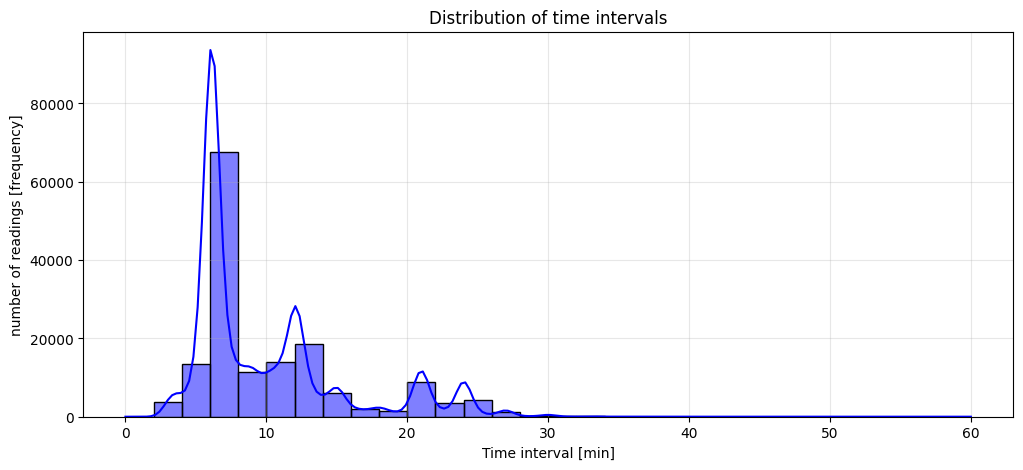

In [ ]:
df_position['Time'] = pd.to_datetime(df_position['Time'])
df_position = df_position.sort_values(by='Time').reset_index(drop=True)
print(f"Data involve the period from {df_position['Time'].min()} to {df_position['Time'].max()}")


df_position['Time_delta'] = df_position['Time'].diff()
df_position['Delta_minutes'] = df_position['Time_delta'].dt.total_seconds() / 60.0
df_position['Delta_minutes'] = df_position['Delta_minutes'].fillna(0)

print("\nBasic statistics for time intervals [minutes]:")
print(df_position['Delta_minutes'].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]))


GAP_THRESHOLD = 120 # if gap/breaks is greater than 2 h (120 min), we assume is a new voyage -- SET TRESHOLD

# how many gaps we have
gaps = df_position[df_position['Delta_minutes'] > GAP_THRESHOLD]
print(f"Found {len(gaps)} gaps/breaks greater than {GAP_THRESHOLD} minutes")


df_position['Voyage_ID'] = (df_position['Delta_minutes'] > GAP_THRESHOLD).cumsum()

print(f"Data have been splitted into {df_position['Voyage_ID'].nunique()} unique voyages")

plt.figure(figsize = (12, 5))

normal_deltas = df_position[df_position['Delta_minutes'] <= 60]['Delta_minutes']
sns.histplot(normal_deltas, bins = 30, color = 'blue', kde = True)
plt.title('Distribution of time intervals')
plt.xlabel('Time interval [min]')
plt.ylabel('number of readings [frequency]')
plt.grid(True, alpha = 0.3)
plt.show()

df_position.to_csv('/content/PositionReport_segmented.csv', index=False)

The histogram above shows the distribution of various time intervals. The x-axis defines the time interval, measured in minutes, whereas y-axis shows the number of readings (frequency) present. The results presents are as follows:

- The major peak on the graph is around 6-8 minutes, with the median in 7 minute. This means that the position reporting system on this ship operated with the constant frequency.

- The graph presents smaller peaks around 14 minutes, 21 minutes, and 28 minutes. These are presumably not errors in data but rather some smaller signal distortions. This checks out as if the signal is sent every 7 minutes and if one packet of signal does not reach the satellite or shore station, the next gap will be exactly 14 minutes. The next peak is the loss of two packets in a row, so 28 minutes.

- The ship rarely loses the entire signal on the high seas as the number of instances above 30 minutes are scarce.



## 2. Kinematic analysis

The analysis of Flettner rotors efficiency makes operational sense only in offshore conditions. This is the situation where the ship keeps the cruising speed (prędkość przelotowa) and is exposed to stable winds.
Nevertheless, some telemetric data contains lots of point from period of maneuvering in ports, work at anchorages and stays at the quay. If we include these phases in our machine learning model, they would lower the predicted average vessel speed and distort the correlation between wind force and speed over ground (SOG).

Therefore, the aim is to assess the speed profile of the given ship. More precisely, we would like to distinguish the "noise", thus stops and maneuvers, from the actual signal - the 'cross-sea' traffic (ruch przelotowy). Thanks to that, we can isolate the seagoing cruises data.

We achieved this by creating the SOG histogram, which identified the natural operational treshold of the ship. Next, based on the bimodal distribution analysis, we adopted a hard cut-off threshold of 5 knots. Our algorithm rejected all records where SOG < 5 kn. The time intervals between the remaining points were then recalculated by us. This defined a new voyage each time the ship stayed in a port or other low-speed zone for a longer period of time.


Rejected 31779 records (20.2%), where shop was stationary or maneuvering
125163 records left in the seagoing movement.
Finally extracted 635 seagoing voyages


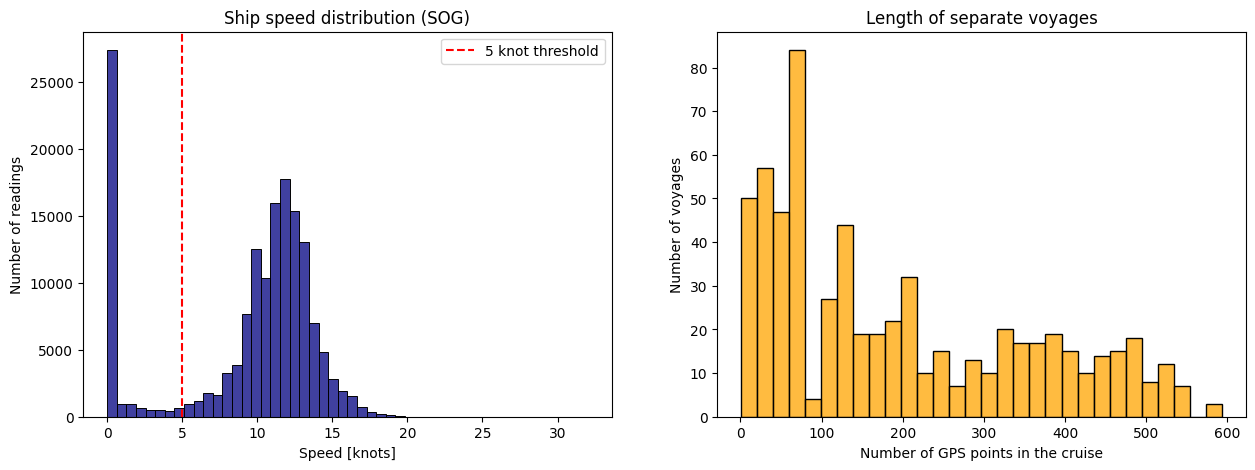

In [ ]:
plt.figure(figsize = (15, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_position['Speed_kn'], bins = 50, color = 'navy', kde = False)
plt.title('Ship speed ​​distribution (SOG)')
plt.xlabel('Speed [knots]')
plt.ylabel('Number of readings')
plt.axvline(x = 5, color = 'red', linestyle = '--', label = '5 knot threshold')
plt.legend()


df_moving = df_position[df_position['Speed_kn'] >= 5.0].copy()
odrzucone = len(df_position) - len(df_moving)
print(f"Rejected {odrzucone} records ({odrzucone/len(df_position)*100:.1f}%), where shop was stationary or maneuvering")
print(f"{len(df_moving)} records left in the seagoing movement.")


df_moving = df_moving.sort_values(by = 'Time').reset_index(drop = True)
df_moving['Time_delta_moving'] = df_moving['Time'].diff().dt.total_seconds() / 60.0
df_moving['Time_delta_moving'] = df_moving['Time_delta_moving'].fillna(0)

# setting the threshold to 4 hours (240 minutes). If the vessel slows below 5 knots for more than 4 hours, it completed 1 voyage and begin a new one after departure
PORT_STAY_THRESHOLD = 240

df_moving['Voyage_ID_final'] = (df_moving['Time_delta_moving'] > PORT_STAY_THRESHOLD).cumsum()

print(f"Finally extracted {df_moving['Voyage_ID_final'].nunique()} seagoing voyages")


plt.subplot(1, 2, 2)
voyage_counts = df_moving.groupby('Voyage_ID_final').size()
sns.histplot(voyage_counts, bins = 30, color = 'orange')
plt.title('Length of separate voyages')
plt.xlabel('Number of GPS points in the cruise')
plt.ylabel('Number of voyages')

plt.show()

df_moving.to_csv('/content/PositionReport_final.csv', index=False)

Above, we can see two histograms. The histogram on the left side exhibits the SOG distribution. On the x-axis the distribution of speed measured in knots is presented, while on the y-axis we can observe the number of readings. On the other hand, the histogram on the right side presents the length of different ship cruises. Here, the x-axis shows number of GPS points in the voyage and y-axis exhibts voyages number. The results the following:

- The speed histogram shows the double-sided nature of how the ship works. We can clearly see the significant line within the interval of 0-2 knots, which represent the stands, drifts or moors and Gaussian distribution with the peak around 11-13 knots. And this second area is the crusing speed (prędkość przelotowa). Moreover, the red treshold line around 5 knots, separating the noise from valuable data.   

- As seen from the data, 31779 records were rejected, which consititues of 20.2% of all data. If we leave 20% of the data, this would teach our model the false assumption that strong winds cause speed to drop to zero.


- The various lengths of cruises histogram shows that our algorithm identified 635 independent cruises. The histogram is skewed to the right. Short cruises dominate, but there is also a thick tail of long cruises. Such a number of independent cruises may serve us to create a reasonable train/test split with division by unique trip IDs. This will also prevent any data leakage as required by the project.

## 3. Route visualization

In this point, we wanted to understand the dominant sailing patterns of a ship. We generated two spatial visualizations based on filtered offshore data (SOG $\ge$ 5 kn). The first scatter plot allows the observation of the shape of the routes. The second is a *Hexbin* plot (aggregation in a hexagonal grid), which uses a color scale to highlight the densest highways of the sea.

North edge (max latitude): 61.2325
South edge (min latitude): 51.0392
East edge (max longitude): 11.2009
West edge (min longitude): -2.1215


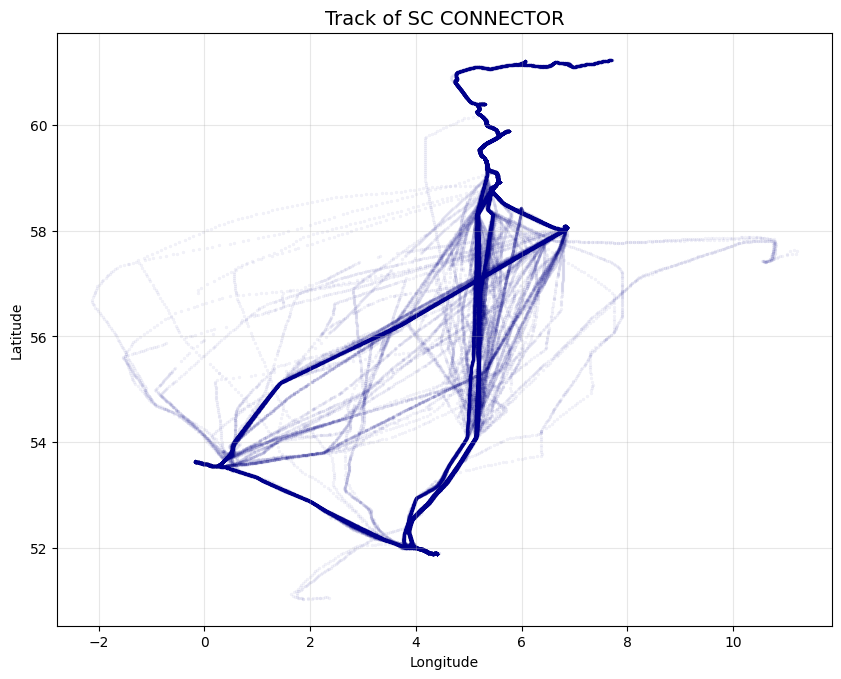

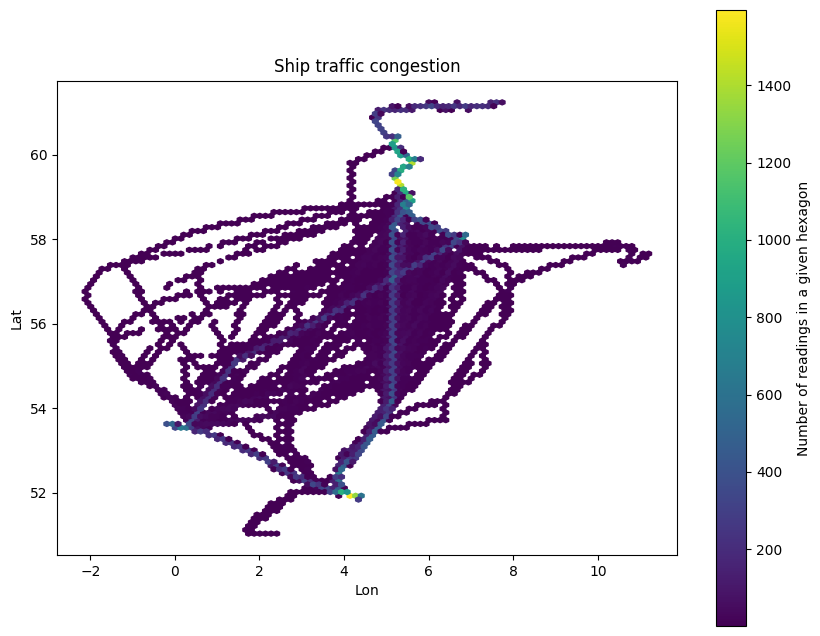

In [ ]:
min_lat = df_moving['Lat_dec'].min()
max_lat = df_moving['Lat_dec'].max()
min_lon = df_moving['Lon_dec'].min()
max_lon = df_moving['Lon_dec'].max()

print(f"North edge (max latitude): {max_lat:.4f}")
print(f"South edge (min latitude): {min_lat:.4f}")
print(f"East edge (max longitude): {max_lon:.4f}")
print(f"West edge (min longitude): {min_lon:.4f}")

plt.figure(figsize = (10, 8))

# where the ship swim the most
sns.scatterplot(data=df_moving, x = 'Lon_dec', y = 'Lat_dec', s = 5, alpha = 0.05, color = 'darkblue', edgecolor = None)

plt.title('Track of SC CONNECTOR', fontsize = 14)
plt.xlabel('Longitude')
plt.ylabel('Latitude')


plt.gca().set_aspect('equal', adjustable = 'box')

plt.grid(True, alpha = 0.3)
plt.show()


plt.figure(figsize=(10, 8))
plt.hexbin(df_moving['Lon_dec'], df_moving['Lat_dec'], gridsize = 100, cmap = 'viridis', mincnt = 1)
plt.colorbar(label='Number of readings in a given hexagon')
plt.title('Ship traffic congestion') # hexbin plot
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

The conclusions from the graphs above presents the following:
- The area from 51.0°N to 61.2°N and from 2.1°W to 11.2°E perfectly covers the North Sea area, from the coast of Great Britain, through the Benelux countries, to Norway and Denmark.

- The Hexbin plot shows that the SC CONNECTOR ship does not travel randomly. Instead, vertical corridor at approximately 5°E is visible, as well as diagonal routes connecting west and east. Light green/yellow hexagons present the most dense nodes of over 1000 readings in one area.

## 4. Ship's course changes (polar plot)

Flettner rotors, based on the Magnus effect, generate the greatest thrust in crosswinds (abeam), but become ineffective when the winds blow directly towards the bow or stern of the ship. Before combining the data with weather models, we must verify whether the ship's navigation profile even offers a chance of favorable wind angles of attack.
Thus, we wanted to show the distribution of ship's courses frequency and determine dominant navigation axes of a ship in the North Sea.

For the methodoly part we took the data from the `Course_deg` column, from 0° to 360°, and we aggregated them into 10-degree bins. These bins were then visualized on a polar plot. There, the radius of the bar corresponds to the number of GPS readings on a given course and the orientation corresponds to true geographic directions.

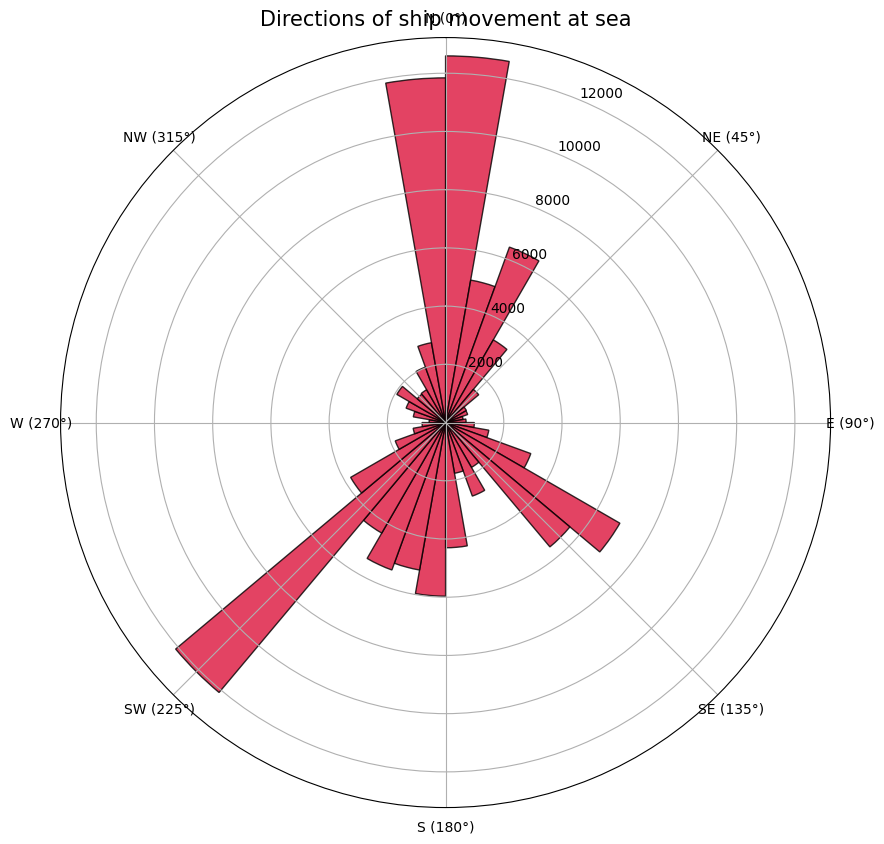


The most common route of the ship is around 5 degrees


In [ ]:

# intervals every 10 degrees [0, 360]
intervals = np.arange(0, 370, 10)

counts, interval_edges = np.histogram(df_moving['Course_deg'].dropna(), bins=intervals)

interval_centers_deg = (interval_edges[:-1] + interval_edges[1:]) / 2
interval_centers_rad = np.deg2rad(interval_centers_deg)
width_rad = np.deg2rad(10)

plt.figure(figsize=(10, 10))
ax = plt.subplot(111, polar = True)


ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)

bars = ax.bar(interval_centers_rad, counts, width = width_rad, bottom = 0.0, alpha = 0.8, color = 'crimson', edgecolor = 'black')

ax.set_xticks(np.deg2rad(np.arange(0, 360, 45)))
ax.set_xticklabels(['N (0°)', 'NE (45°)', 'E (90°)', 'SE (135°)', 'S (180°)', 'SW (225°)', 'W (270°)', 'NW (315°)'])
plt.title('Directions of ship movement at sea', va = 'bottom', fontsize = 15)

plt.show()

dom_course = interval_centers_deg[np.argmax(counts)]
print(f"\nThe most common route of the ship is around {dom_course:.0f} degrees")

The results from the polar graph are as follows:
- The graph shows that the ship is not moving uniformly in all directions. Two axes of motion stand out: North-South axis and North East - South West axis.

- Climatological data show that the North Sea is dominated by strong winds from the westerlies for most of the year. Since the ship sails predominantly N-S direction, this means that the prevailing winds will strike the ship's side at an angle close to 90 degrees - abeam wind.



## 5. Speed ​​vs. course (SOG vs. COG)

Understanding which directions ships sail most often is only half the story. To optimally design a wind propulsion system, we need to understand its actual speed profiles in various navigation scenarios. For example, a ship may sail slower upwind or against a current, but faster downwind, even with the same engine settings.

Thus, our main aim is to detect the relationship between a vessel's heading (COG) and its speed over ground (SOG). Next, we need to isolate the dominant operational modes, so-called "kinematic steady states", and eventually create a polar density map of velocity for the ship.


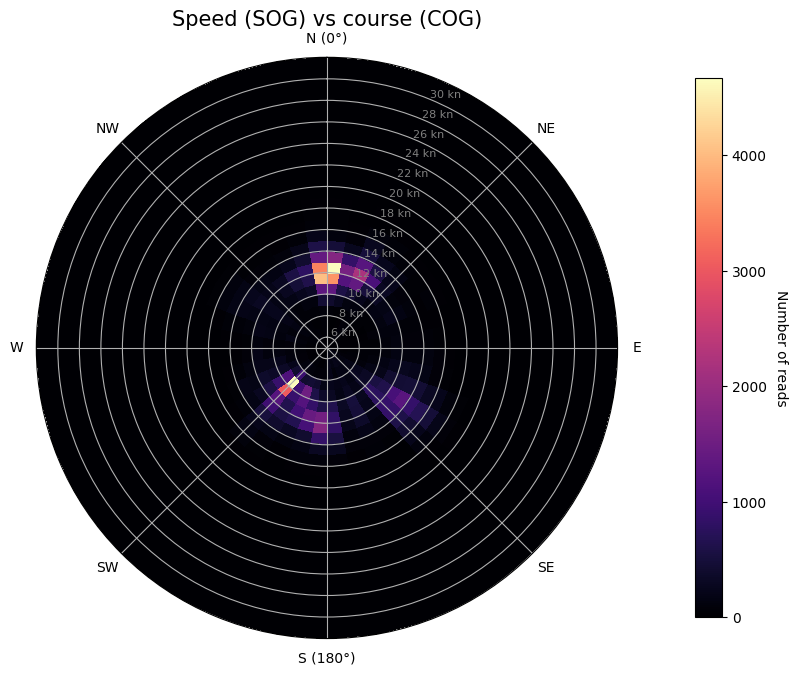

In [ ]:
df_plot = df_moving.dropna(subset=['Course_deg', 'Speed_kn']).copy()

course_rad = np.deg2rad(df_plot['Course_deg'])
speed = df_plot['Speed_kn']


theta_bins = np.linspace(0, 2 * np.pi, 37)

max_speed = np.ceil(speed.max())
r_bins = np.linspace(5, max_speed, int(max_speed - 5 + 1))


H, theta_edges, r_edges = np.histogram2d(course_rad, speed, bins=[theta_bins, r_bins])


fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': 'polar'})
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)


T, R = np.meshgrid(theta_edges, r_edges)

c = ax.pcolormesh(T, R, H.T, cmap='magma', shading='flat')


ax.set_xticks(np.deg2rad(np.arange(0, 360, 45)))
ax.set_xticklabels(['N (0°)', 'NE', 'E', 'SE', 'S (180°)', 'SW', 'W', 'NW'])
ax.set_rmin(5)
ax.set_yticks(np.arange(6, max_speed, 2))
ax.set_yticklabels([f"{int(s)} kn" for s in np.arange(6, max_speed, 2)], color='grey', size=8)

cbar = plt.colorbar(c, ax=ax, pad=0.1, shrink=0.7)
cbar.set_label('Number of reads', rotation=270, labelpad=15)

plt.title('Speed (SOG) vs course (COG)', va='bottom', fontsize=15, pad=20)
plt.show()

The results discussion:

- The greatest concentration of data, indicated by the intense yellow spot,  occurs around COG heading **~180° - 210° (South-Southwest)** at SOG speeds **~14 - 16 knots**.

- A second distinct, though smaller, cluster of data (green-yellow spot) is visible at COG courses **~0° - 20° (North)** at lower SOG speeds **~11 - 13 knots**. When heading north, the vessel moves on average about 3 knots slower than when heading southwest.